In [1]:
import json
import time
import warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

INPUT_DIR = Path("../runs/processed/sample_split")

RESULTS_DIR = Path("../runs/results/knn_baseline")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Input dir:", INPUT_DIR)
print("Results dir:", RESULTS_DIR)

Input dir: ..\runs\processed\sample_split
Results dir: ..\runs\results\knn_baseline


In [2]:
#데이터 불러오기
X_train_sample = pd.read_csv(INPUT_DIR / "X_train_sample.csv")
X_val_sample = pd.read_csv(INPUT_DIR / "X_val_sample.csv")
X_test_sample = pd.read_csv(INPUT_DIR / "X_test_sample.csv")

y_train_sample = pd.read_csv(INPUT_DIR / "y_train_sample.csv").squeeze()
y_val_sample = pd.read_csv(INPUT_DIR / "y_val_sample.csv").squeeze()
y_test_sample = pd.read_csv(INPUT_DIR / "y_test_sample.csv").squeeze()

print("X_train_sample:", X_train_sample.shape)
print("X_val_sample:", X_val_sample.shape)
print("X_test_sample:", X_test_sample.shape)

print("y_train_sample:", y_train_sample.shape)
print("y_val_sample:", y_val_sample.shape)
print("y_test_sample:", y_test_sample.shape)

X_train_sample: (100000, 52)
X_val_sample: (30000, 52)
X_test_sample: (30000, 52)
y_train_sample: (100000,)
y_val_sample: (30000,)
y_test_sample: (30000,)


In [3]:
# sample feature 

X_train_knn = X_train_sample
X_val_knn = X_val_sample
X_test_knn = X_test_sample

print("KNN baseline will use original sample features without scaling.")
print("X_train_knn:", X_train_knn.shape)
print("X_val_knn:", X_val_knn.shape)
print("X_test_knn:", X_test_knn.shape)

KNN baseline will use original sample features without scaling.
X_train_knn: (100000, 52)
X_val_knn: (30000, 52)
X_test_knn: (30000, 52)


In [4]:
#평가함수 정의
def evaluate_knn_result(y_true, y_pred, model_name, dataset_name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    result = {
        "model": model_name,
        "dataset": dataset_name,
        "accuracy": accuracy,
        "precision_attack": precision,
        "recall_attack": recall,
        "f1_attack": f1,
        "fpr": fpr,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }
    
    return result, cm

In [5]:
#validation set 에서 k 비교
k_values = [3, 5, 7, 9, 11]
validation_results = []

for k in k_values:
    print(f"Training KNN with k={k}")
    
    start_time = time.time()
    
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights="uniform",
        metric="minkowski",
        p=2,
        n_jobs=-1
    )
    
    knn.fit(X_train_knn, y_train_sample)
    y_val_pred = knn.predict(X_val_knn)
    
    elapsed_time = time.time() - start_time
    
    result, _ = evaluate_knn_result(
        y_true=y_val_sample,
        y_pred=y_val_pred,
        model_name=f"KNN_k{k}",
        dataset_name="validation_sample"
    )
    
    result["elapsed_time_sec"] = elapsed_time
    validation_results.append(result)

knn_validation_results = pd.DataFrame(validation_results)
knn_validation_results = knn_validation_results.sort_values(
    by="f1_attack",
    ascending=False
).reset_index(drop=True)

Training KNN with k=3
Training KNN with k=5
Training KNN with k=7
Training KNN with k=9
Training KNN with k=11


In [6]:
#validation 결과 표
report_table = knn_validation_results.copy()

report_table["Model"] = (
    report_table["model"]
    .str.replace("KNN_k", "KNN (k=", regex=False)
    + ")"
)
report_table = report_table[[
    "Model",
    "accuracy",
    "precision_attack",
    "recall_attack",
    "f1_attack",
    "fpr",
    "fp",
    "fn"
]]

report_table.columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "FPR",
    "FP",
    "FN"
]

styled_report_table = (
    report_table.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "FPR": "{:.4f}"
    })
    .set_properties(**{
        "background-color": "white",
        "color": "black",
        "border": "1px solid black",
        "text-align": "center",
        "font-size": "11pt"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#E6E6E6"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("font-size", "12pt"),
                ("border", "1px solid black"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto")
            ]
        }
    ])
)

styled_report_table

,Model,Accuracy,Precision,Recall,F1-score,FPR,FP,FN
0,KNN (k=3),0.9855,0.9511,0.9639,0.9575,0.0101,251,183
1,KNN (k=5),0.9839,0.9440,0.9619,0.9529,0.0116,289,193
2,KNN (k=7),0.9823,0.9383,0.9582,0.9481,0.0128,319,212
3,KNN (k=9),0.9811,0.9359,0.9534,0.9446,0.0133,331,236
4,KNN (k=11),0.9800,0.9331,0.9497,0.9413,0.0138,345,255


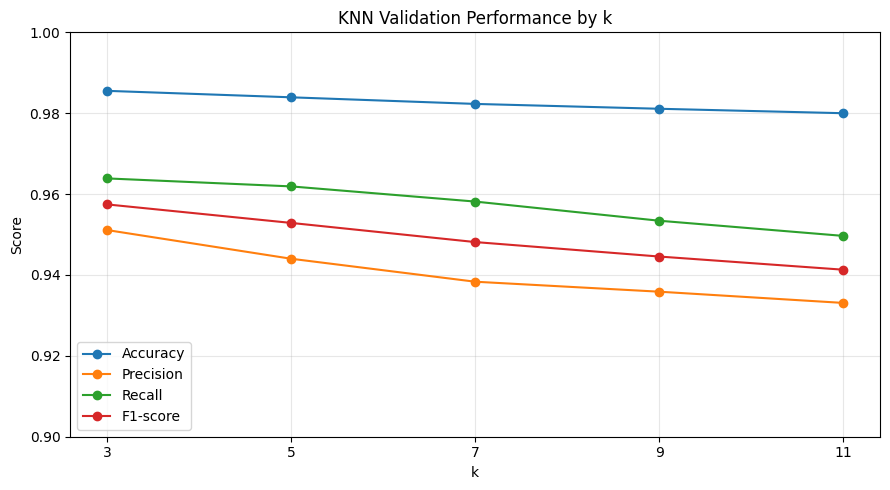

In [7]:
#k별 성능 그래프 

plot_df = knn_validation_results.copy()
plot_df["k"] = plot_df["model"].str.replace("KNN_k", "").astype(int)
plot_df = plot_df.sort_values("k")

plt.figure(figsize=(9, 5))

plt.plot(plot_df["k"], plot_df["accuracy"], marker="o", label="Accuracy")
plt.plot(plot_df["k"], plot_df["precision_attack"], marker="o", label="Precision")
plt.plot(plot_df["k"], plot_df["recall_attack"], marker="o", label="Recall")
plt.plot(plot_df["k"], plot_df["f1_attack"], marker="o", label="F1-score")

plt.title("KNN Validation Performance by k")
plt.xlabel("k")
plt.ylabel("Score")
plt.xticks(plot_df["k"])
plt.ylim(0.90, 1.00)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

In [8]:
# Best k 선택
best_k_row = knn_validation_results.iloc[0]

best_k = int(
    best_k_row["model"]
    .replace("KNN_k", "")
)

print("Best k selected by validation F1-score:", best_k)

display(best_k_row.to_frame().T)

# Save validation results
knn_validation_results.to_csv(
    RESULTS_DIR / "knn_validation_results.csv",
    index=False
)

# Save best k
with open(RESULTS_DIR / "knn_best_k.json", "w", encoding="utf-8") as f:
    json.dump({"best_k": best_k}, f, indent=4)

print("Saved validation results:", RESULTS_DIR / "knn_validation_results.csv")
print("Saved best k:", RESULTS_DIR / "knn_best_k.json")



Best k selected by validation F1-score: 3


,model,dataset,accuracy,precision_attack,recall_attack,f1_attack,fpr,tn,fp,fn,tp,elapsed_time_sec
0,KNN_k3,validation_sample,0.985533,0.95111,0.963877,0.957451,0.010067,24683,251,183,4883,4.367173


Saved validation results: ..\runs\results\knn_baseline\knn_validation_results.csv
Saved best k: ..\runs\results\knn_baseline\knn_best_k.json


In [9]:
#test set에 대한 평가 진행
best_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    weights="uniform",
    metric="minkowski",
    p=2,
    n_jobs=-1
)

# Train
best_knn.fit(X_train_knn, y_train_sample)

# Predict
y_test_pred = best_knn.predict(X_test_knn)

# Evaluate
knn_test_result, knn_test_cm = evaluate_knn_result(
    y_true=y_test_sample,
    y_pred=y_test_pred,
    model_name=f"KNN_k{best_k}",
    dataset_name="test_sample"
)

In [10]:
# DataFrame
knn_test_results = pd.DataFrame([knn_test_result])

# Table
final_test_table = knn_test_results.copy()

final_test_table["Model"] = (
    final_test_table["model"]
    .str.replace("KNN_k", "KNN (k=", regex=False)
    + ")"
)

final_test_table = final_test_table[[
    "Model",
    "accuracy",
    "precision_attack",
    "recall_attack",
    "f1_attack",
    "fpr",
    "fp",
    "fn"
]]

final_test_table.columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "FPR",
    "FP",
    "FN"
]

styled_final_test_table = (
    final_test_table.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "FPR": "{:.4f}"
    })
    .set_properties(**{
        "background-color": "white",
        "color": "black",
        "border": "1px solid black",
        "text-align": "center",
        "font-size": "11pt"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#E6E6E6"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("font-size", "12pt"),
                ("border", "1px solid black"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto")
            ]
        }
    ])
)

display(styled_final_test_table)


,Model,Accuracy,Precision,Recall,F1-score,FPR,FP,FN
0,KNN (k=3),0.9858,0.9512,0.9657,0.9584,0.0101,251,174


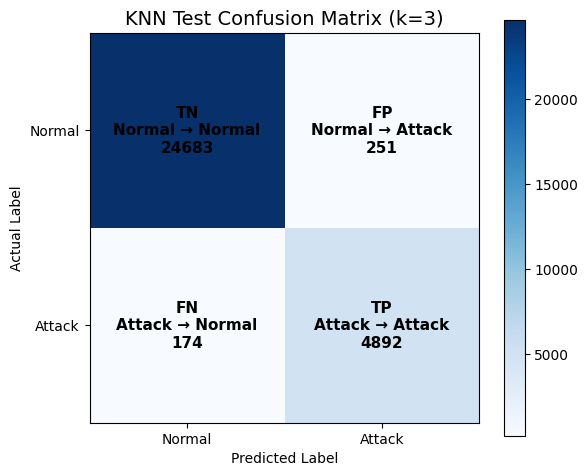

In [11]:
# Confusion Matrix Visualization

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(knn_test_cm, cmap="Blues")

ax.set_title(f"KNN Test Confusion Matrix (k={best_k})", fontsize=14)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Normal", "Attack"])
ax.set_yticklabels(["Normal", "Attack"])

labels = [
    ["TN\nNormal → Normal", "FP\nNormal → Attack"],
    ["FN\nAttack → Normal", "TP\nAttack → Attack"]
]

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            f"{labels[i][j]}\n{knn_test_cm[i, j]}",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold"
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [12]:
#test 결과 표 
test_report_table = knn_test_results.copy()

test_report_table["Model"] = (
    test_report_table["model"]
    .str.replace("KNN_k", "KNN (k=", regex=False)
    + ")"
)

test_report_table = test_report_table[[
    "Model",
    "accuracy",
    "precision_attack",
    "recall_attack",
    "f1_attack",
    "fpr",
    "fp",
    "fn"
]]

test_report_table.columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "FPR",
    "FP",
    "FN"
]

styled_test_results = (
    test_report_table.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "FPR": "{:.4f}"
    })
    .set_properties(**{
        "background-color": "white",
        "color": "black",
        "border": "1px solid black",
        "text-align": "center",
        "font-size": "11pt"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#E6E6E6"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("font-size", "12pt"),
                ("border", "1px solid black"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto")
            ]
        }
    ])
)

styled_test_results

,Model,Accuracy,Precision,Recall,F1-score,FPR,FP,FN
0,KNN (k=3),0.9858,0.9512,0.9657,0.9584,0.0101,251,174


In [13]:
#test 결과 저장 
knn_test_results.to_csv(
    RESULTS_DIR / "knn_test_results.csv",
    index=False
)

pd.DataFrame({
    "y_true": y_test_sample,
    "y_pred": y_test_pred
}).to_csv(
    RESULTS_DIR / "knn_test_predictions.csv",
    index=False
)

pd.DataFrame(
    knn_test_cm,
    index=["Actual_Normal_0", "Actual_Attack_1"],
    columns=["Pred_Normal_0", "Pred_Attack_1"]
).to_csv(
    RESULTS_DIR / "knn_test_confusion_matrix.csv",
    index=True
)

print("Saved test results:", RESULTS_DIR / "knn_test_results.csv")
print("Saved test predictions:", RESULTS_DIR / "knn_test_predictions.csv")
print("Saved confusion matrix:", RESULTS_DIR / "knn_test_confusion_matrix.csv")

Saved test results: ..\runs\results\knn_baseline\knn_test_results.csv
Saved test predictions: ..\runs\results\knn_baseline\knn_test_predictions.csv
Saved confusion matrix: ..\runs\results\knn_baseline\knn_test_confusion_matrix.csv


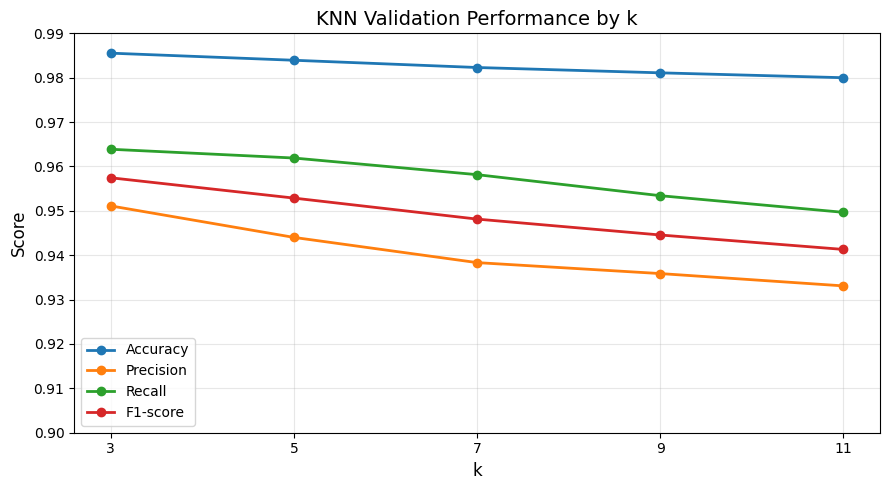

Saved plot: ..\runs\results\knn_baseline\knn_validation_metrics.png


In [14]:
#validation 성능 그래프 저장

plot_df = knn_validation_results.copy()

plot_df["k"] = (
    plot_df["model"]
    .str.replace("KNN_k", "", regex=False)
    .astype(int)
)

plot_df = plot_df.sort_values("k")

plt.figure(figsize=(9, 5))

plt.plot(
    plot_df["k"],
    plot_df["accuracy"],
    marker="o",
    linewidth=2,
    label="Accuracy"
)

plt.plot(
    plot_df["k"],
    plot_df["precision_attack"],
    marker="o",
    linewidth=2,
    label="Precision"
)

plt.plot(
    plot_df["k"],
    plot_df["recall_attack"],
    marker="o",
    linewidth=2,
    label="Recall"
)

plt.plot(
    plot_df["k"],
    plot_df["f1_attack"],
    marker="o",
    linewidth=2,
    label="F1-score"
)

plt.title("KNN Validation Performance by k", fontsize=14)

plt.xlabel("k", fontsize=12)
plt.ylabel("Score", fontsize=12)

plt.xticks(plot_df["k"])

# 핵심 수정 부분
plt.ylim(0.90, 0.99)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "knn_validation_metrics.png",
    dpi=300
)

plt.show()

print("Saved plot:", RESULTS_DIR / "knn_validation_metrics.png")

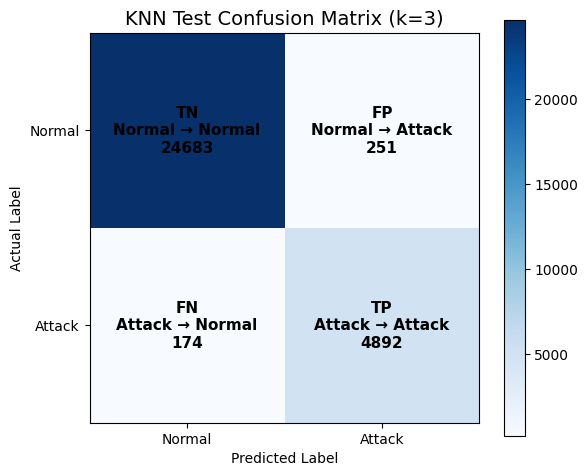

Saved plot: ..\runs\results\knn_baseline\knn_test_confusion_matrix.png


In [15]:
# Test confusion matrix  저장
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(knn_test_cm, cmap="Blues")

ax.set_title(f"KNN Test Confusion Matrix (k={best_k})", fontsize=14)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Normal", "Attack"])
ax.set_yticklabels(["Normal", "Attack"])

labels = [
    ["TN\nNormal → Normal", "FP\nNormal → Attack"],
    ["FN\nAttack → Normal", "TP\nAttack → Attack"]
]

for i in range(2):
    for j in range(2):
        ax.text(
            j, i,
            f"{labels[i][j]}\n{knn_test_cm[i, j]}",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold"
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()

plt.savefig(RESULTS_DIR / "knn_test_confusion_matrix.png", dpi=300)
plt.show()

print("Saved plot:", RESULTS_DIR / "knn_test_confusion_matrix.png")

In [16]:
#최종 요약 저장
knn_summary = {
    "model": "KNN baseline",
    "data_source": "sample data generated by 00_eda.ipynb",
    "train_sample": "X_train_sample.csv, y_train_sample.csv",
    "validation_sample": "X_val_sample.csv, y_val_sample.csv",
    "test_sample": "X_test_sample.csv, y_test_sample.csv",
    "k_values": k_values,
    "best_k": best_k,
    "selection_metric": "validation f1_attack",
    "test_result": knn_test_result
}

with open(RESULTS_DIR / "knn_baseline_summary.json", "w", encoding="utf-8") as f:
    json.dump(knn_summary, f, indent=4, ensure_ascii=False)

print("KNN baseline experiment completed.")
print("Saved summary:", RESULTS_DIR / "knn_baseline_summary.json")

KNN baseline experiment completed.
Saved summary: ..\runs\results\knn_baseline\knn_baseline_summary.json
